# 02 — Exploratory Data Analysis

This notebook describes what the **historical NGCP data actually show** before any simulation is used. It compares demand magnitude, daily shape, weekday/weekend behavior, and peak-hour behavior across the three study periods.

### What to look for
- Differences in **average and maximum MW** across periods.
- Whether the 24-hour curve changes shape, not just level.
- Whether weekdays and weekends behave differently.
- Whether the most common **NGCP Hour No.** for daily peaks shifts across periods.

In [7]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
if not (project_root / "src" / "data_preparation.py").is_file():
    project_root = project_root.parent
if not (project_root / "src" / "data_preparation.py").is_file():
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import PERIOD_ORDER
figures_dir = project_root / "figures"
results_dir = project_root / "results"
figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)

from src.eda import period_summary, hourly_profile, day_type_profile, daily_peaks, peak_hour_distribution

df = pd.read_csv(project_root / "data/processed/luzon_hourly_clean.csv", parse_dates=["date", "datetime"])
df["ngcp_hour_no"] = df["hour"] + 1
summary = period_summary(df)
pre_mean = float(summary.loc[summary["period"] == "Pre-pandemic", "mean_mw"].iloc[0])
summary["mean_change_vs_pre_pct"] = (summary["mean_mw"] / pre_mean - 1) * 100
summary.round(2)

,period,observations,mean_mw,median_mw,std_mw,min_mw,max_mw,mean_change_vs_pre_pct
0,Pre-pandemic,26280,7858.47,7866.5,1260.52,4077.0,11301.0,0.00
1,Pandemic,17544,8055.74,8067.0,1174.25,2694.0,11599.0,2.51
2,Recovery,26304,9262.99,9235.5,1407.56,4879.0,13957.0,17.87


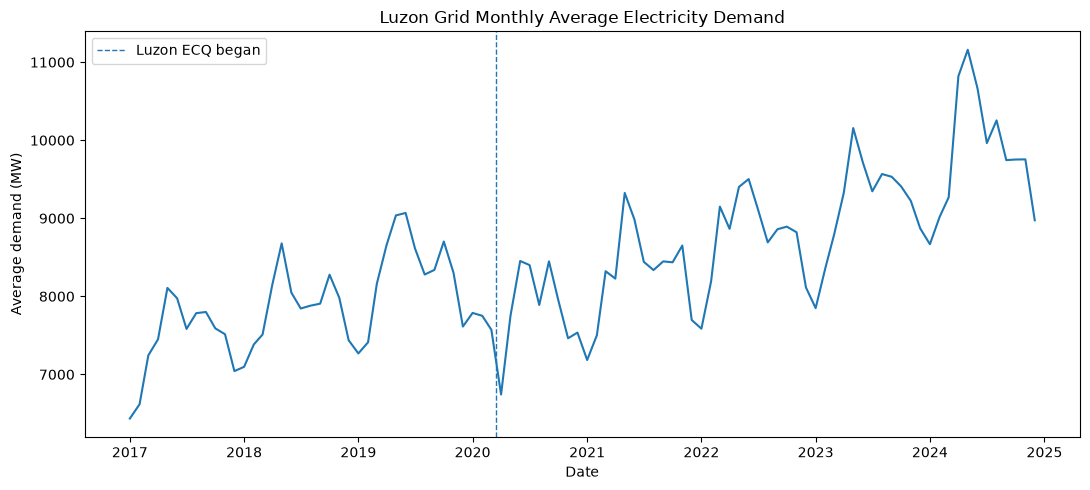

In [8]:
monthly = df.set_index("datetime").groupby(pd.Grouper(freq="MS"))["demand_mw"].mean()
plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly.values)
plt.axvline(pd.Timestamp("2020-03-17"), linestyle="--", linewidth=1, label="Luzon ECQ began")
plt.title("Luzon Grid Monthly Average Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Average demand (MW)")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "eda_monthly_demand_trend.png", dpi=160)
plt.show()

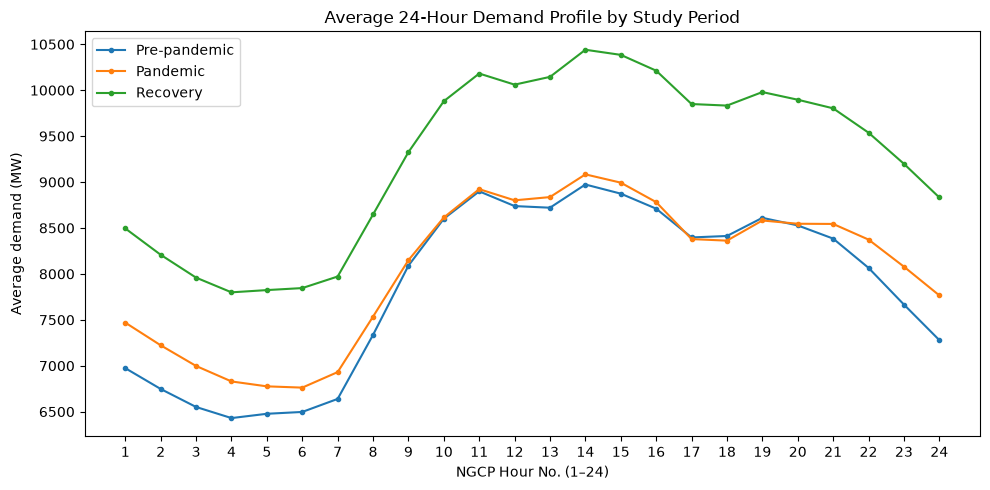

In [9]:
prof = hourly_profile(df).copy()
prof["NGCP Hour No."] = prof["hour"] + 1
plt.figure(figsize=(10, 5))
for period in PERIOD_ORDER:
    part = prof[prof["period"] == period]
    plt.plot(part["NGCP Hour No."], part["demand_mw"], marker="o", markersize=3, label=period)
plt.title("Average 24-Hour Demand Profile by Study Period")
plt.xlabel("NGCP Hour No. (1–24)")
plt.ylabel("Average demand (MW)")
plt.xticks(range(1, 25))
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "eda_absolute_24h_profiles.png", dpi=160)
plt.show()

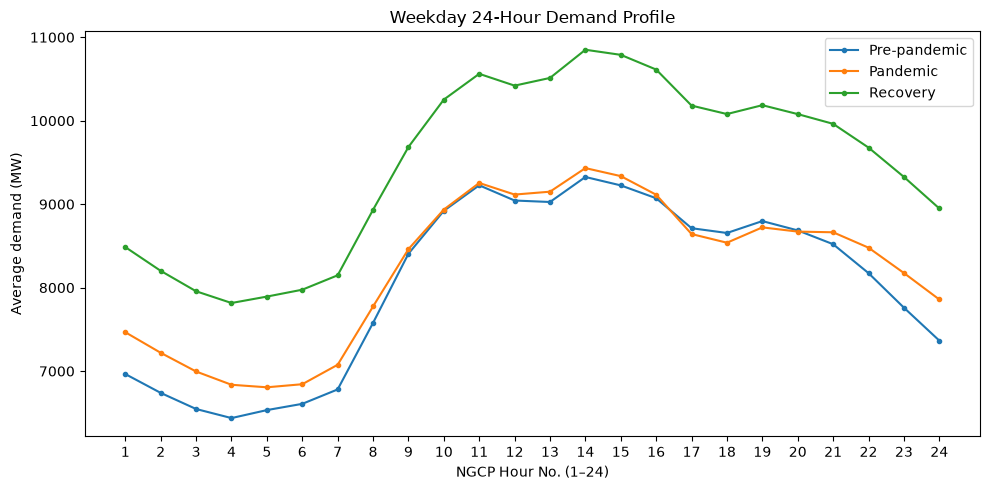

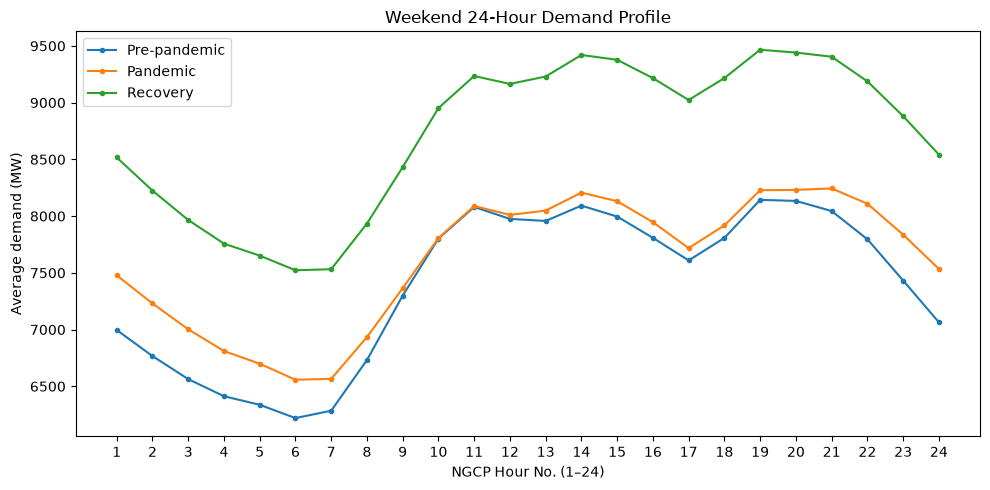

In [10]:
dt = day_type_profile(df).copy()
dt["NGCP Hour No."] = dt["hour"] + 1
for day_type in ["Weekday", "Weekend"]:
    plt.figure(figsize=(10, 5))
    for period in PERIOD_ORDER:
        part = dt[(dt["period"] == period) & (dt["day_type"] == day_type)]
        plt.plot(part["NGCP Hour No."], part["demand_mw"], marker="o", markersize=3, label=period)
    plt.title(f"{day_type} 24-Hour Demand Profile")
    plt.xlabel("NGCP Hour No. (1–24)")
    plt.ylabel("Average demand (MW)")
    plt.xticks(range(1, 25))
    plt.legend()
    plt.tight_layout()
    plt.savefig(figures_dir / f"eda_{day_type.lower()}_profiles.png", dpi=160)
    plt.show()

In [11]:
peaks = peak_hour_distribution(df).copy()
peaks["NGCP Hour No."] = peaks["peak_hour"] + 1
top_peaks = (
    peaks.sort_values(["period", "share"], ascending=[True, False])
         .groupby("period", observed=True)
         .head(5)[["period", "NGCP Hour No.", "days", "share"]]
)
top_peaks["share_pct"] = top_peaks["share"] * 100
top_peaks.drop(columns="share").round(2)

,period,NGCP Hour No.,days,share_pct
5,Pandemic,14,406,55.54
3,Pandemic,11,125,17.10
12,Pandemic,21,64,8.76
10,Pandemic,19,49,6.70
6,Pandemic,15,26,3.56
18,Pre-pandemic,14,622,56.80
17,Pre-pandemic,11,240,21.92
22,Pre-pandemic,19,86,7.85
23,Pre-pandemic,20,66,6.03
24,Pre-pandemic,21,35,3.20


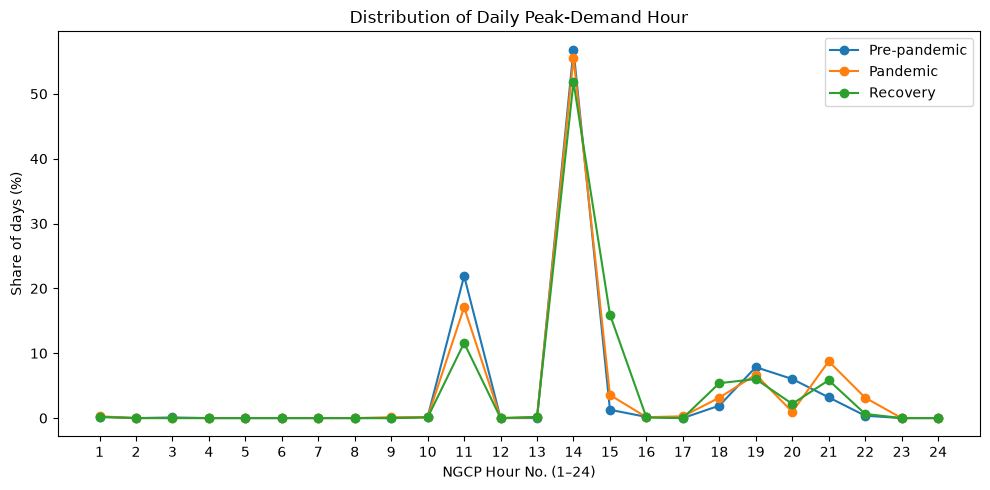

In [12]:
plt.figure(figsize=(10, 5))
for period in PERIOD_ORDER:
    shares = peaks[peaks["period"] == period].set_index("NGCP Hour No.")["share"].reindex(range(1, 25), fill_value=0)
    plt.plot(range(1, 25), shares * 100, marker="o", label=period)
plt.title("Distribution of Daily Peak-Demand Hour")
plt.xlabel("NGCP Hour No. (1–24)")
plt.ylabel("Share of days (%)")
plt.xticks(range(1, 25))
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "eda_peak_hour_distribution.png", dpi=160)
plt.show()

In [13]:
summary.to_csv(results_dir / "period_summary.csv", index=False)
prof.to_csv(results_dir / "hourly_profile_absolute.csv", index=False)
dt.to_csv(results_dir / "day_type_profile_absolute.csv", index=False)
peaks.to_csv(results_dir / "peak_hour_distribution.csv", index=False)

print("KEY HISTORICAL FINDINGS")
for _, row in summary.iterrows():
    print(f"- {row['period']}: mean={row['mean_mw']:.1f} MW, max={row['max_mw']:.1f} MW, variability (SD)={row['std_mw']:.1f} MW")
for period in PERIOD_ORDER:
    p = peaks[peaks['period'] == period].sort_values('share', ascending=False).iloc[0]
    print(f"- {period}: most common daily peak = NGCP Hour No. {int(p['NGCP Hour No.'])} ({p['share']*100:.1f}% of days)")
print(f"- Recovery mean demand is {(summary.loc[summary.period=='Recovery','mean_mw'].iloc[0]/pre_mean-1)*100:.1f}% above the pre-pandemic mean.")

KEY HISTORICAL FINDINGS
- Pre-pandemic: mean=7858.5 MW, max=11301.0 MW, variability (SD)=1260.5 MW
- Pandemic: mean=8055.7 MW, max=11599.0 MW, variability (SD)=1174.3 MW
- Recovery: mean=9263.0 MW, max=13957.0 MW, variability (SD)=1407.6 MW
- Pre-pandemic: most common daily peak = NGCP Hour No. 14 (56.8% of days)
- Pandemic: most common daily peak = NGCP Hour No. 14 (55.5% of days)
- Recovery: most common daily peak = NGCP Hour No. 14 (51.8% of days)
- Recovery mean demand is 17.9% above the pre-pandemic mean.
